# 05 — Modeling
Train XGBoost, LightGBM, CatBoost on engineered features.  
Temporal train/test split, TimeSeriesSplit CV, ensemble, ablation, error analysis.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, os, pickle, time
warnings.filterwarnings('ignore')
from sklearn.calibration import calibration_curve

from sklearn.metrics import (accuracy_score, log_loss, roc_auc_score,
                             brier_score_loss, classification_report,
                             confusion_matrix)
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

DATA = './data/' if os.path.exists('./data/model_data.csv') else '../data/'
df = pd.read_csv(f'{DATA}model_data.csv', parse_dates=['event_date'])
df = df.sort_values('event_date').reset_index(drop=True)

print(f"Loaded: {df.shape}")
print(f"Date range: {df.event_date.min().date()} to {df.event_date.max().date()}")
print(f"Target mean (f1_win): {df.f1_win.mean():.3f}")
print(f"Baseline (always pick red): {df.f1_win.mean():.1%}")


Loaded: (5485, 322)
Date range: 2015-01-03 to 2026-04-11
Target mean (f1_win): 0.571
Baseline (always pick red): 57.1%


## Feature Selection & Temporal Split
Train on 2015–2023, test on 2024–2026.  
Exclude identity columns, string categoricals, and raw in-fight stats.


In [3]:
# ── Temporal split ──
TRAIN_END = '2023-12-31'
train = df[df.event_date <= TRAIN_END].copy()
test  = df[df.event_date >  TRAIN_END].copy()

print(f"Train: {len(train)} fights  ({train.event_date.min().date()} → {train.event_date.max().date()})")
print(f"Test:  {len(test)} fights  ({test.event_date.min().date()} → {test.event_date.max().date()})")
print(f"Train red WR: {train.f1_win.mean():.3f}")
print(f"Test  red WR: {test.f1_win.mean():.3f}")

# ── Columns to EXCLUDE ──
# Identity / target / post-fight info
IDENTITY = ['event_name', 'event_date', 'fight_url', 'fighter_1', 'fighter_2',
            'winner', 'f1_win', 'method_clean', 'finish_type', 'round', 'time',
            'time_seconds', 'total_time_seconds', 'weight_class',
            'stance_matchup', 'f1_stance', 'f2_stance']

# Raw in-fight stats (current fight — would be leakage)
IN_FIGHT = [c for c in df.columns if any(c.startswith(p) for p in [
    'f1_kd','f2_kd','f1_sub','f2_sub','f1_str_','f2_str_',
    'f1_total_str','f2_total_str','f1_td_','f2_td_',
    'f1_head_','f2_head_','f1_body_','f2_body_',
    'f1_leg_','f2_leg_','f1_distance_','f2_distance_',
    'f1_clinch_','f2_clinch_','f1_ground_','f2_ground_',
    'f1_ctrl_','f2_ctrl_','f1_rev','f2_rev'])]

EXCLUDE = set(IDENTITY + IN_FIGHT)

# ── Feature lists ──
all_features = sorted([c for c in df.columns if c not in EXCLUDE])
diff_features = [c for c in all_features if c.startswith('diff_')]
profile_features = [c for c in all_features if 'profile' in c]
rolling_features = [c for c in diff_features if 'profile' not in c]
physical_features = [c for c in diff_features if any(k in c for k in
                     ['height','reach','age','ape','weight_lbs'])]

print(f"\nFeature counts:")
print(f"  All features:      {len(all_features)}")
print(f"  Diff features:     {len(diff_features)}")
print(f"  Profile features:  {len(profile_features)}")
print(f"  Rolling diffs:     {len(rolling_features)}")
print(f"  Physical diffs:    {len(physical_features)}")

# ── Sanity: no leaky columns ──
leaky_check = [f for f in all_features if f in EXCLUDE]
assert len(leaky_check) == 0, f"Leaky columns in features: {leaky_check}"
print(f"\nLeakage check: PASSED ✅ (0 excluded columns in feature set)")

TARGET = 'f1_win'
X_train, y_train = train[all_features], train[TARGET]
X_test,  y_test  = test[all_features],  test[TARGET]

# Baseline
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
baseline_probs = np.full(len(y_test), y_train.mean())
baseline_ll = log_loss(y_test, baseline_probs)
print(f"\nTest baseline accuracy (always red): {baseline_acc:.3f}")
print(f"Test baseline log loss (calibrated):  {baseline_ll:.3f}")


Train: 4319 fights  (2015-01-03 → 2023-12-16)
Test:  1166 fights  (2024-01-13 → 2026-04-11)
Train red WR: 0.576
Test  red WR: 0.552

Feature counts:
  All features:      310
  Diff features:     101
  Profile features:  30
  Rolling diffs:     91
  Physical diffs:    5

Leakage check: PASSED ✅ (0 excluded columns in feature set)

Test baseline accuracy (always red): 0.552
Test baseline log loss (calibrated):  0.689


## Cross-Validation Setup
TimeSeriesSplit respects temporal ordering — no future leakage in CV folds.


In [4]:
def temporal_cv(model_fn, X, y, n_splits=5, label='Model'):
    """TimeSeriesSplit CV. model_fn(X_tr, y_tr) → fitted model."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = {'accuracy': [], 'log_loss': [], 'roc_auc': [], 'brier': []}

    print(f"\n{'='*60}")
    print(f"{label} — {n_splits}-Fold TimeSeriesSplit CV")
    print(f"{'='*60}")

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = model_fn(X_tr, y_tr)

        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_val)[:, 1]
        else:
            probs = model.predict(X_val)

        preds = (probs >= 0.5).astype(int)
        fold_baseline = max(y_val.mean(), 1 - y_val.mean())

        results['accuracy'].append(accuracy_score(y_val, preds))
        results['log_loss'].append(log_loss(y_val, probs))
        results['roc_auc'].append(roc_auc_score(y_val, probs))
        results['brier'].append(brier_score_loss(y_val, probs))

        print(f"  Fold {fold+1}: n={len(val_idx):>4d}  "
              f"acc={results['accuracy'][-1]:.3f} (base={fold_baseline:.3f})  "
              f"AUC={results['roc_auc'][-1]:.3f}  "
              f"logloss={results['log_loss'][-1]:.3f}")

    for metric in results:
        results[metric] = np.array(results[metric])

    print(f"\n  MEAN ± STD:")
    print(f"    Accuracy:  {results['accuracy'].mean():.3f} ± {results['accuracy'].std():.3f}")
    print(f"    AUC:       {results['roc_auc'].mean():.3f} ± {results['roc_auc'].std():.3f}")
    print(f"    Log Loss:  {results['log_loss'].mean():.3f} ± {results['log_loss'].std():.3f}")
    print(f"    Brier:     {results['brier'].mean():.3f} ± {results['brier'].std():.3f}")

    return results, model  # returns last fold's model (largest training set)


## XGBoost
Conservative hyperparameters: depth 5, 500 trees, regularization on.  
XGBoost handles NaN natively.


In [5]:
def train_xgb(X_tr, y_tr):
    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=1.0,
        min_child_weight=5,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_tr, y_tr, verbose=False)
    return model

t0 = time.time()
xgb_cv, _ = temporal_cv(train_xgb, X_train, y_train, label='XGBoost')

# Final model on all training data
xgb_model = train_xgb(X_train, y_train)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

print(f"\n  TEST SET:")
print(f"    Accuracy:  {accuracy_score(y_test, xgb_preds):.3f}  (baseline: {baseline_acc:.3f})")
print(f"    AUC:       {roc_auc_score(y_test, xgb_probs):.3f}")
print(f"    Log Loss:  {log_loss(y_test, xgb_probs):.3f}")
print(f"    Time:      {time.time()-t0:.1f}s")



XGBoost — 5-Fold TimeSeriesSplit CV
  Fold 1: n= 719  acc=0.655 (base=0.569)  AUC=0.707  logloss=0.697
  Fold 2: n= 719  acc=0.651 (base=0.538)  AUC=0.708  logloss=0.691
  Fold 3: n= 719  acc=0.704 (base=0.605)  AUC=0.756  logloss=0.592
  Fold 4: n= 719  acc=0.695 (base=0.577)  AUC=0.758  logloss=0.602
  Fold 5: n= 719  acc=0.716 (base=0.583)  AUC=0.799  logloss=0.538

  MEAN ± STD:
    Accuracy:  0.684 ± 0.026
    AUC:       0.746 ± 0.035
    Log Loss:  0.624 ± 0.061
    Brier:     0.211 ± 0.021

  TEST SET:
    Accuracy:  0.751  (baseline: 0.552)
    AUC:       0.828
    Log Loss:  0.513
    Time:      57.9s


## LightGBM
Similar hyperparameters. LightGBM uses NaN as a native split direction.


In [6]:
def train_lgb(X_tr, y_tr):
    model = lgb.LGBMClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=1.0,
        min_child_samples=20,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(X_tr, y_tr)
    return model

t0 = time.time()
lgb_cv, _ = temporal_cv(train_lgb, X_train, y_train, label='LightGBM')

lgb_model = train_lgb(X_train, y_train)
lgb_probs = lgb_model.predict_proba(X_test)[:, 1]
lgb_preds = (lgb_probs >= 0.5).astype(int)

print(f"\n  TEST SET:")
print(f"    Accuracy:  {accuracy_score(y_test, lgb_preds):.3f}  (baseline: {baseline_acc:.3f})")
print(f"    AUC:       {roc_auc_score(y_test, lgb_probs):.3f}")
print(f"    Log Loss:  {log_loss(y_test, lgb_probs):.3f}")
print(f"    Time:      {time.time()-t0:.1f}s")



LightGBM — 5-Fold TimeSeriesSplit CV
  Fold 1: n= 719  acc=0.640 (base=0.569)  AUC=0.698  logloss=0.744
  Fold 2: n= 719  acc=0.652 (base=0.538)  AUC=0.704  logloss=0.714
  Fold 3: n= 719  acc=0.677 (base=0.605)  AUC=0.746  logloss=0.609
  Fold 4: n= 719  acc=0.687 (base=0.577)  AUC=0.751  logloss=0.620
  Fold 5: n= 719  acc=0.716 (base=0.583)  AUC=0.792  logloss=0.547

  MEAN ± STD:
    Accuracy:  0.675 ± 0.027
    AUC:       0.738 ± 0.034
    Log Loss:  0.647 ± 0.072
    Brier:     0.217 ± 0.023

  TEST SET:
    Accuracy:  0.746  (baseline: 0.552)
    AUC:       0.831
    Log Loss:  0.511
    Time:      31.8s


## CatBoost
auto_class_weights='Balanced' tested here to see if it helps blue-corner recall.


In [7]:
def train_cat(X_tr, y_tr):
    model = cb.CatBoostClassifier(
        iterations=500,
        depth=5,
        learning_rate=0.05,
        subsample=0.8,
        l2_leaf_reg=3.0,
        random_seed=42,
        verbose=0,
        eval_metric='Logloss',
        auto_class_weights='Balanced',
    )
    model.fit(X_tr, y_tr)
    return model

t0 = time.time()
cat_cv, _ = temporal_cv(train_cat, X_train, y_train, label='CatBoost')

cat_model = train_cat(X_train, y_train)
cat_probs = cat_model.predict_proba(X_test)[:, 1]
cat_preds = (cat_probs >= 0.5).astype(int)

print(f"\n  TEST SET:")
print(f"    Accuracy:  {accuracy_score(y_test, cat_preds):.3f}  (baseline: {baseline_acc:.3f})")
print(f"    AUC:       {roc_auc_score(y_test, cat_probs):.3f}")
print(f"    Log Loss:  {log_loss(y_test, cat_probs):.3f}")
print(f"    Time:      {time.time()-t0:.1f}s")



CatBoost — 5-Fold TimeSeriesSplit CV
  Fold 1: n= 719  acc=0.643 (base=0.569)  AUC=0.706  logloss=0.702
  Fold 2: n= 719  acc=0.650 (base=0.538)  AUC=0.712  logloss=0.646
  Fold 3: n= 719  acc=0.690 (base=0.605)  AUC=0.748  logloss=0.586
  Fold 4: n= 719  acc=0.688 (base=0.577)  AUC=0.758  logloss=0.587
  Fold 5: n= 719  acc=0.705 (base=0.583)  AUC=0.783  logloss=0.550

  MEAN ± STD:
    Accuracy:  0.675 ± 0.025
    AUC:       0.741 ± 0.029
    Log Loss:  0.614 ± 0.053
    Brier:     0.210 ± 0.018

  TEST SET:
    Accuracy:  0.758  (baseline: 0.552)
    AUC:       0.836
    Log Loss:  0.504
    Time:      59.7s


## Model Comparison


In [8]:
models = {
    'XGBoost':  (xgb_preds, xgb_probs, xgb_cv),
    'LightGBM': (lgb_preds, lgb_probs, lgb_cv),
    'CatBoost': (cat_preds, cat_probs, cat_cv),
}

print(f"{'Model':<12} {'CV Acc':>8} {'Test Acc':>9} {'Lift':>7} "
      f"{'AUC':>6} {'LogLoss':>8} {'Brier':>7}")
print("─" * 65)

# Baseline row
print(f"{'Baseline':<12} {'—':>8} {baseline_acc:>9.3f} {'—':>7} "
      f"{'0.500':>6} {baseline_ll:>8.3f} "
      f"{brier_score_loss(y_test, baseline_probs):>7.3f}")

best_name, best_acc = None, 0
for name, (preds, probs, cv) in models.items():
    cv_acc  = cv['accuracy'].mean()
    test_acc = accuracy_score(y_test, preds)
    lift    = test_acc - baseline_acc
    auc     = roc_auc_score(y_test, probs)
    ll      = log_loss(y_test, probs)
    brier   = brier_score_loss(y_test, probs)
    print(f"{name:<12} {cv_acc:>8.3f} {test_acc:>9.3f} {lift:>+7.3f} "
          f"{auc:>6.3f} {ll:>8.3f} {brier:>7.3f}")
    if test_acc > best_acc:
        best_name, best_acc = name, test_acc

print(f"\nBest model by test accuracy: {best_name} ({best_acc:.3f})")


Model          CV Acc  Test Acc    Lift    AUC  LogLoss   Brier
─────────────────────────────────────────────────────────────────
Baseline            —     0.552       —  0.500    0.689   0.248
XGBoost         0.684     0.751  +0.199  0.828    0.513   0.168
LightGBM        0.675     0.746  +0.194  0.831    0.511   0.167
CatBoost        0.675     0.758  +0.206  0.836    0.504   0.164

Best model by test accuracy: CatBoost (0.758)


## Feature Importance
Top 20 features per model, color-coded by feature group.  
Consensus ranking averages rank across all three models.


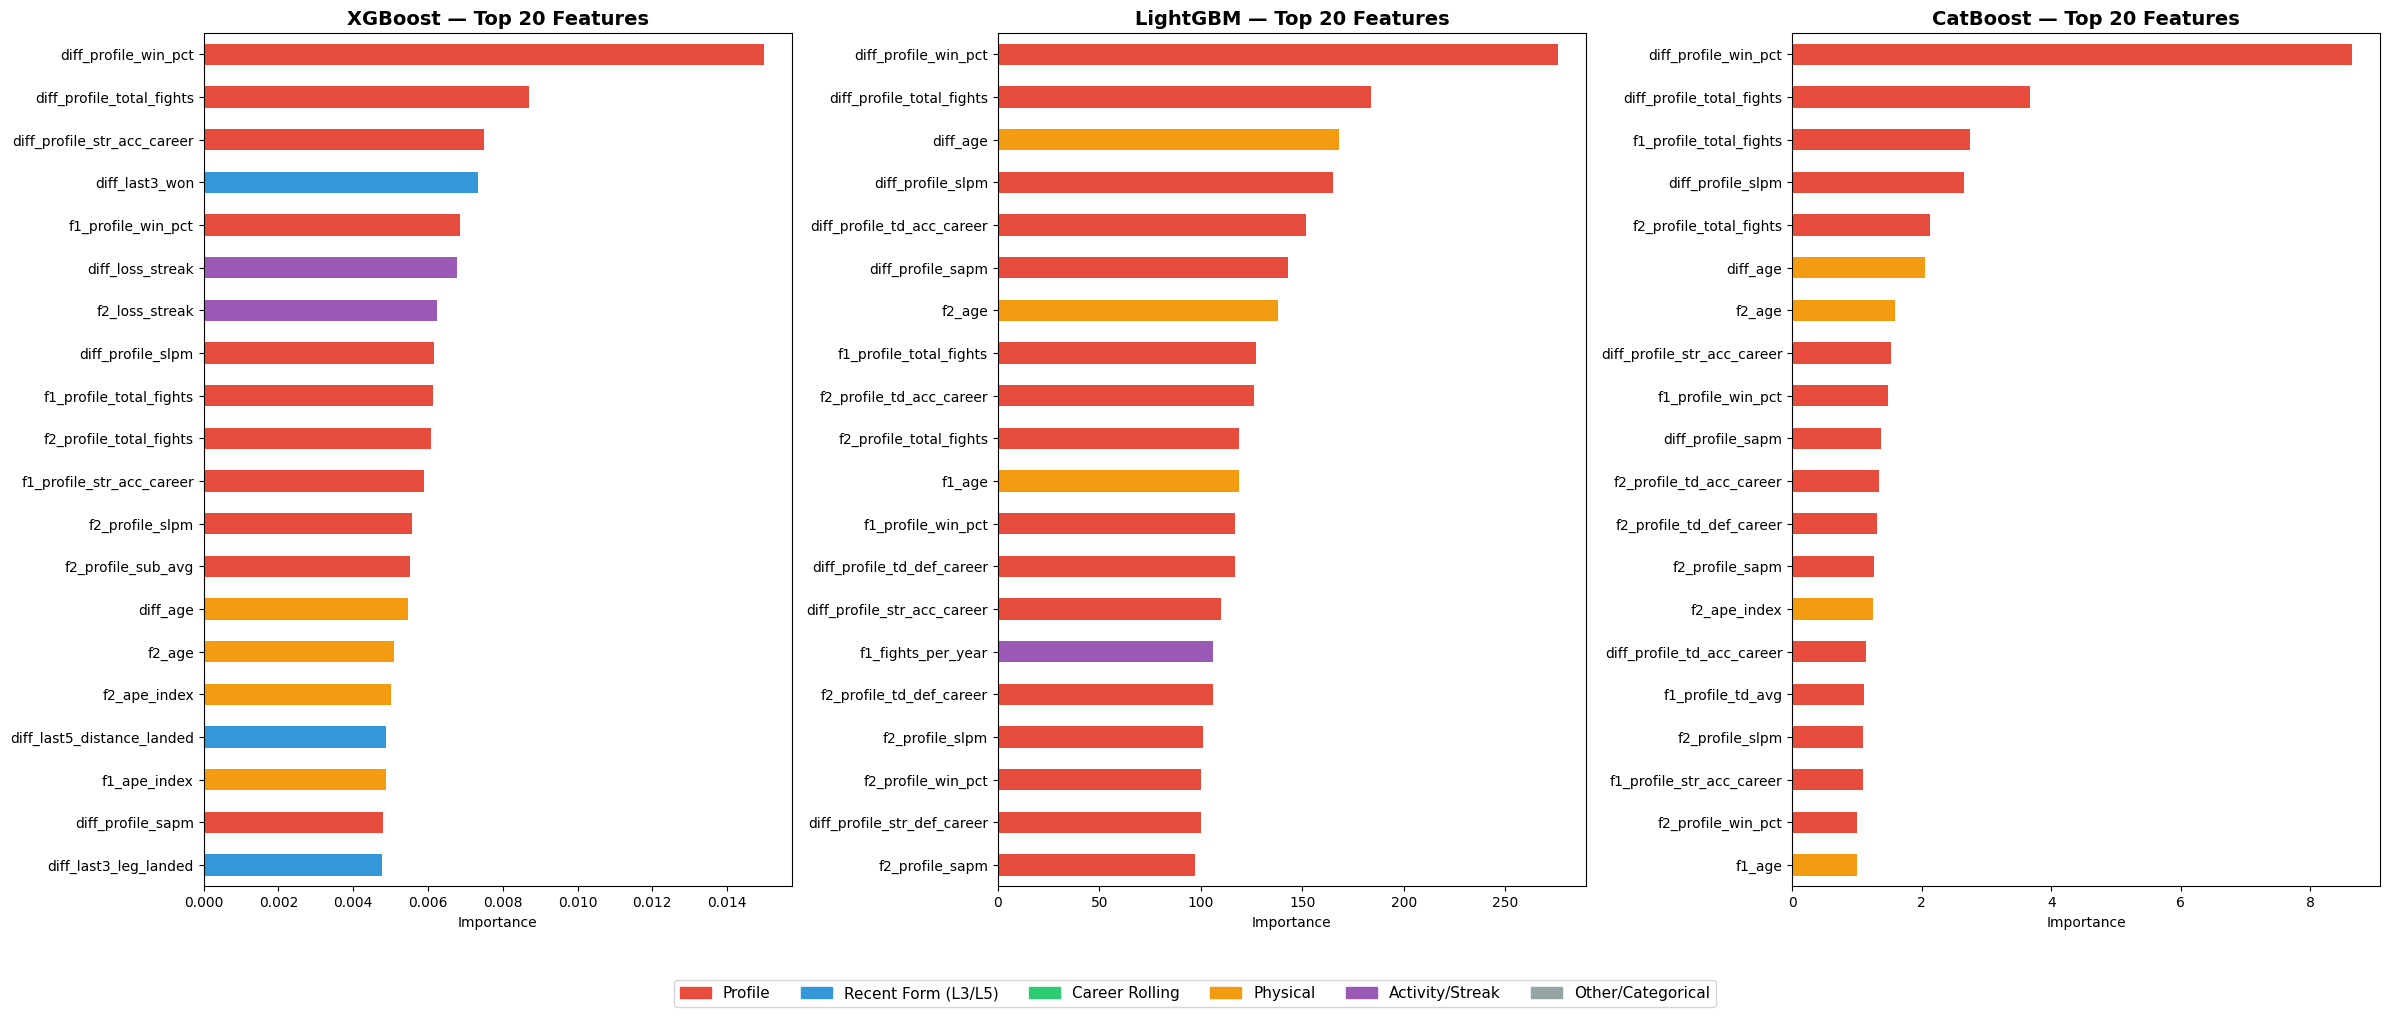


CONSENSUS TOP 15 (average rank across 3 models)
                              avg_rank     group  XGBoost  LightGBM  CatBoost
diff_profile_win_pct          1.000000   PROFILE      1.0       1.0       1.0
diff_profile_total_fights     2.000000   PROFILE      2.0       2.0       2.0
diff_profile_slpm             5.333333   PROFILE      8.0       4.0       4.0
f1_profile_total_fights       6.666667   PROFILE      9.0       8.0       3.0
diff_age                      7.666667  PHYSICAL     14.0       3.0       6.0
diff_profile_str_acc_career   8.333333   PROFILE      3.0      14.0       8.0
f2_profile_total_fights       8.500000   PROFILE     10.0      10.5       5.0
f1_profile_win_pct            8.833333   PROFILE      5.0      12.5       9.0
f2_age                        9.666667  PHYSICAL     15.0       7.0       7.0
diff_profile_sapm            11.666667   PROFILE     19.0       6.0      10.0
f2_profile_slpm              15.333333   PROFILE     12.0      17.0      17.0
f2_profile_td_a

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

def get_color(f):
    if 'profile' in f:   return '#e74c3c'    # red
    if 'last3' in f or 'last5' in f: return '#3498db'  # blue
    if 'career' in f:    return '#2ecc71'    # green
    if any(k in f for k in ['age','height','reach','ape','weight']): return '#f39c12'  # orange
    if any(k in f for k in ['streak','days','fights_per','activity']): return '#9b59b6'  # purple
    return '#95a5a6'  # gray

model_objs = [('XGBoost', xgb_model), ('LightGBM', lgb_model), ('CatBoost', cat_model)]

for ax, (name, model) in zip(axes, model_objs):
    if name == 'CatBoost':
        imp = model.get_feature_importance()
    else:
        imp = model.feature_importances_

    feat_imp = pd.Series(imp, index=all_features).sort_values(ascending=False)
    top20 = feat_imp.head(20)
    colors = [get_color(f) for f in top20.index]

    top20.plot.barh(ax=ax, color=colors)
    ax.set_title(f'{name} — Top 20 Features', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel('Importance')

from matplotlib.patches import Patch
legend_elements = [
    Patch(color='#e74c3c', label='Profile'),
    Patch(color='#3498db', label='Recent Form (L3/L5)'),
    Patch(color='#2ecc71', label='Career Rolling'),
    Patch(color='#f39c12', label='Physical'),
    Patch(color='#9b59b6', label='Activity/Streak'),
    Patch(color='#95a5a6', label='Other/Categorical'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f'{DATA}feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Consensus ranking ──
print("\n" + "="*60)
print("CONSENSUS TOP 15 (average rank across 3 models)")
print("="*60)
ranks = pd.DataFrame()
for name, model in model_objs:
    imp = model.get_feature_importance() if name == 'CatBoost' else model.feature_importances_
    ranks[name] = pd.Series(imp, index=all_features).rank(ascending=False)
ranks['avg_rank'] = ranks.mean(axis=1)
consensus = ranks.sort_values('avg_rank').head(15)
consensus['group'] = [
    'PROFILE' if 'profile' in f else
    'RECENT' if ('last3' in f or 'last5' in f) else
    'CAREER' if 'career' in f else
    'PHYSICAL' if any(k in f for k in ['age','height','reach','ape','weight']) else
    'ACTIVITY' if any(k in f for k in ['streak','days','fights_per']) else
    'OTHER'
    for f in consensus.index
]
print(consensus[['avg_rank', 'group', 'XGBoost', 'LightGBM', 'CatBoost']].to_string())


## Ensemble
Simple average of all three models' predicted probabilities.  
Also check: when all 3 agree, how accurate are they?


In [10]:
print("="*60)
print("ENSEMBLE")
print("="*60)

# ── Simple average ──
ens_probs = (xgb_probs + lgb_probs + cat_probs) / 3
ens_preds = (ens_probs >= 0.5).astype(int)

ens_acc   = accuracy_score(y_test, ens_preds)
ens_auc   = roc_auc_score(y_test, ens_probs)
ens_ll    = log_loss(y_test, ens_probs)
ens_brier = brier_score_loss(y_test, ens_probs)

print(f"Ensemble Accuracy:  {ens_acc:.3f}  (baseline: {baseline_acc:.3f}, lift: {ens_acc - baseline_acc:+.3f})")
print(f"Ensemble AUC:       {ens_auc:.3f}")
print(f"Ensemble Log Loss:  {ens_ll:.3f}")
print(f"Ensemble Brier:     {ens_brier:.3f}")

# ── vs individual models ──
print(f"\n{'Model':<12} {'Accuracy':>9} {'LogLoss':>9}")
print("─" * 32)
for name, (preds, probs, _) in models.items():
    print(f"{name:<12} {accuracy_score(y_test, preds):>9.3f} {log_loss(y_test, probs):>9.3f}")
print(f"{'Ensemble':<12} {ens_acc:>9.3f} {ens_ll:>9.3f}")

# ── Agreement analysis ──
print(f"\nModel agreement:")
agree_all = ((xgb_preds == lgb_preds) & (lgb_preds == cat_preds))
print(f"  XGB-LGB agree: {(xgb_preds == lgb_preds).mean():.1%}")
print(f"  XGB-CAT agree: {(xgb_preds == cat_preds).mean():.1%}")
print(f"  LGB-CAT agree: {(lgb_preds == cat_preds).mean():.1%}")
print(f"  All 3 agree:   {agree_all.mean():.1%} ({agree_all.sum()}/{len(y_test)} fights)")

if agree_all.sum() > 0:
    unan_acc = accuracy_score(y_test[agree_all], xgb_preds[agree_all])
    print(f"  Unanimous accuracy: {unan_acc:.3f}")

# ── Disagreement fights ──
disagree = ~agree_all
if disagree.sum() > 0:
    dis_acc = accuracy_score(y_test[disagree], ens_preds[disagree])
    print(f"  Disagreement fights ({disagree.sum()}): ensemble acc = {dis_acc:.3f}")


ENSEMBLE
Ensemble Accuracy:  0.759  (baseline: 0.552, lift: +0.207)
Ensemble AUC:       0.837
Ensemble Log Loss:  0.499
Ensemble Brier:     0.163

Model         Accuracy   LogLoss
────────────────────────────────
XGBoost          0.751     0.513
LightGBM         0.746     0.511
CatBoost         0.758     0.504
Ensemble         0.759     0.499

Model agreement:
  XGB-LGB agree: 92.6%
  XGB-CAT agree: 88.0%
  LGB-CAT agree: 89.0%
  All 3 agree:   84.8% (989/1166 fights)
  Unanimous accuracy: 0.794
  Disagreement fights (177): ensemble acc = 0.565


## Calibration
How well do predicted probabilities match actual outcomes?  
Well-calibrated probabilities are essential for betting applications.


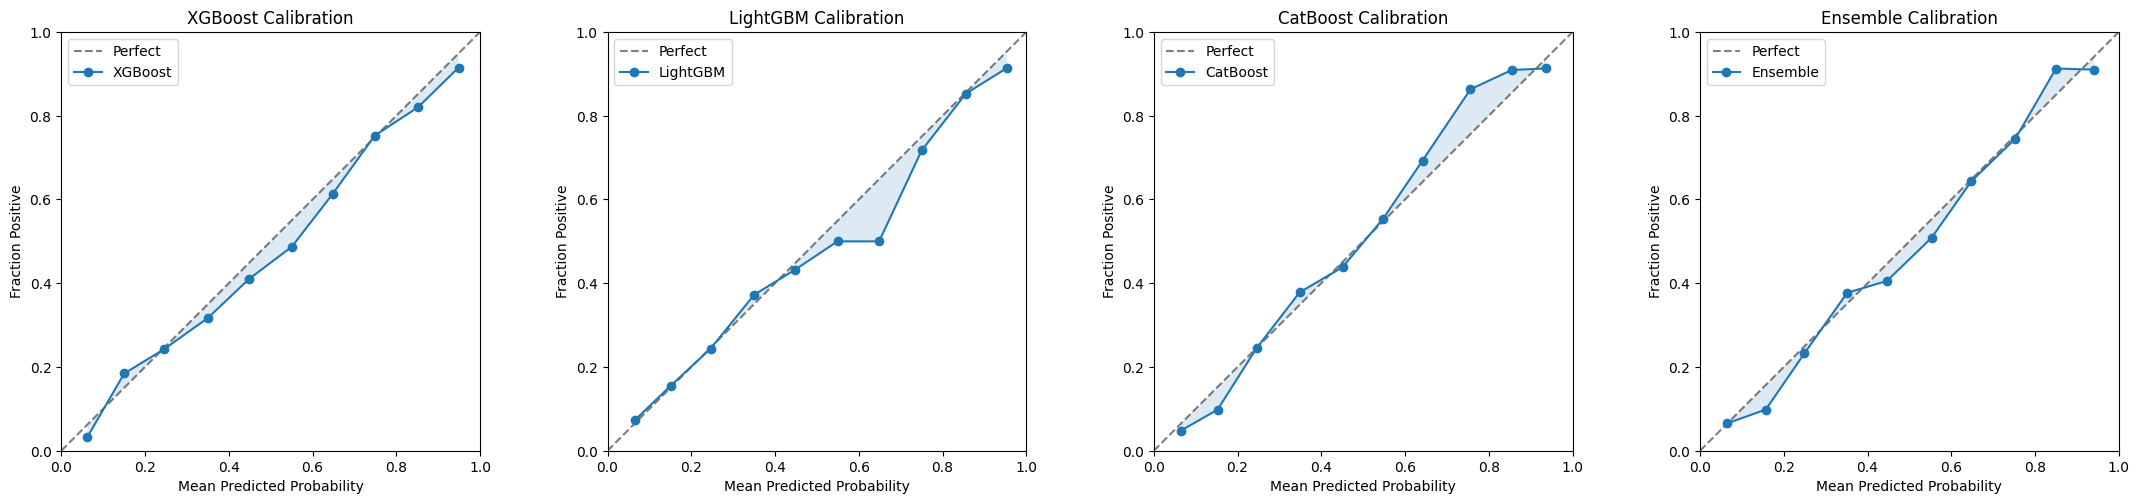


CONFIDENCE BUCKET ANALYSIS (Ensemble)
        fights  accuracy  avg_prob  pct_of_fights
bucket                                           
50-53%      51     0.569     0.515            4.4
53-57%     107     0.561     0.550            9.2
57-62%     115     0.557     0.595            9.9
62-68%     130     0.654     0.649           11.1
68-75%     150     0.667     0.715           12.9
75%+       613     0.892     0.869           52.6

Key insight: Fights where model is >62% confident should show >60% accuracy
if the model has genuine predictive power beyond the baseline.


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

all_models = list(models.items()) + [('Ensemble', (ens_preds, ens_probs, None))]

for ax, (name, (_, probs, _)) in zip(axes, all_models):
    fraction_pos, mean_predicted = calibration_curve(y_test, probs, n_bins=10, strategy='uniform')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.plot(mean_predicted, fraction_pos, 'o-', markersize=6, label=name)
    ax.fill_between(mean_predicted, fraction_pos, [mp for mp in mean_predicted],
                    alpha=0.15)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction Positive')
    ax.set_title(f'{name} Calibration')
    ax.legend(loc='upper left')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{DATA}calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confidence bucket analysis ──
print("\n" + "="*60)
print("CONFIDENCE BUCKET ANALYSIS (Ensemble)")
print("="*60)

bucket_df = pd.DataFrame({
    'prob': ens_probs,
    'pred': ens_preds,
    'actual': y_test.values,
    'correct': (ens_preds == y_test.values).astype(int),
    'confidence': np.abs(ens_probs - 0.5),
})

bins = [0, 0.03, 0.07, 0.12, 0.18, 0.25, 0.50]
labels = ['50-53%', '53-57%', '57-62%', '62-68%', '68-75%', '75%+']
bucket_df['bucket'] = pd.cut(bucket_df['confidence'], bins=bins, labels=labels)

bucket_stats = bucket_df.groupby('bucket', observed=True).agg(
    fights=('actual', 'count'),
    accuracy=('correct', 'mean'),
    avg_prob=('prob', lambda x: np.abs(x - 0.5).mean() + 0.5),
).round(3)
bucket_stats['pct_of_fights'] = (bucket_stats['fights'] / len(y_test) * 100).round(1)
print(bucket_stats.to_string())
print(f"\nKey insight: Fights where model is >62% confident should show >60% accuracy")
print(f"if the model has genuine predictive power beyond the baseline.")


## Ablation Study
Test whether profile features (potential leakage) are inflating performance.  
If "No Profile" matches "All Features", the model isn't relying on leaky data.


In [12]:
print("="*60)
print("ABLATION STUDY")
print("="*60)

feature_sets = {
    'All features': all_features,
    'No profile': [f for f in all_features if 'profile' not in f],
    'Diffs only': diff_features,
    'Diffs no profile': [f for f in diff_features if 'profile' not in f],
    'Profile only': [f for f in all_features if 'profile' in f] + 
                    ['weight_class_ord', 'f1_stance_enc', 'f2_stance_enc',
                     'ortho_vs_south', 'has_switch'],
    'Physical + activity only': [f for f in all_features if any(k in f for k in
                    ['height','reach','age','ape','weight','streak','days','fights_per',
                     'weight_class_ord','stance_enc','ortho','switch'])],
}

# Clean feature sets — only keep columns that exist
for k in feature_sets:
    feature_sets[k] = [f for f in feature_sets[k] if f in df.columns]

ablation = {}
for set_name, features in feature_sets.items():
    model = lgb.LGBMClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7,
        reg_alpha=1.0, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbosity=-1,
    )
    model.fit(train[features], y_train)
    probs = model.predict_proba(test[features])[:, 1]
    preds = (probs >= 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    ll  = log_loss(y_test, probs)
    ablation[set_name] = {'n_feat': len(features), 'acc': acc, 'auc': auc, 'logloss': ll}
    print(f"  {set_name:<25s} ({len(features):>3d} feat)  acc={acc:.3f}  AUC={auc:.3f}  ll={ll:.3f}")

print(f"\n  Baseline: acc={baseline_acc:.3f}")
abl_df = pd.DataFrame(ablation).T
abl_df['lift_vs_base'] = abl_df['acc'] - baseline_acc
print(f"\n{abl_df.to_string()}")

profile_impact = ablation['All features']['acc'] - ablation['No profile']['acc']
print(f"\nProfile impact: {profile_impact:+.3f}")
if abs(profile_impact) < 0.01:
    print("→ Profile features contribute <1% — model is NOT relying on leaky data ✅")
elif profile_impact > 0.02:
    print("→ Profile features add >2% — potential leakage concern ⚠️")
    print("  Consider using profile features only as cold-start fallback")
else:
    print("→ Profile features contribute 1-2% — marginal, likely safe")


ABLATION STUDY
  All features              (310 feat)  acc=0.746  AUC=0.831  ll=0.511
  No profile                (280 feat)  acc=0.634  AUC=0.651  ll=0.670
  Diffs only                (101 feat)  acc=0.739  AUC=0.821  ll=0.516
  Diffs no profile          ( 91 feat)  acc=0.606  AUC=0.632  ll=0.679
  Profile only              ( 35 feat)  acc=0.730  AUC=0.812  ll=0.535
  Physical + activity only  ( 32 feat)  acc=0.607  AUC=0.627  ll=0.687

  Baseline: acc=0.552

                          n_feat       acc       auc   logloss  lift_vs_base
All features               310.0  0.746141  0.831346  0.511382      0.193825
No profile                 280.0  0.633791  0.651094  0.670014      0.081475
Diffs only                 101.0  0.739280  0.821256  0.516497      0.186964
Diffs no profile            91.0  0.606346  0.631564  0.679021      0.054031
Profile only                35.0  0.729846  0.811740  0.535304      0.177530
Physical + activity only    32.0  0.607204  0.627228  0.687226      0.054

## Error Analysis
Where does the model fail? Confident wrong predictions, accuracy by weight class,
by finish type, and over time.


In [13]:
print("="*60)
print("ERROR ANALYSIS")
print("="*60)

# Use ensemble for analysis
err = test.copy()
err['ens_prob'] = ens_probs
err['ens_pred'] = ens_preds
err['correct'] = (err['ens_pred'] == err['f1_win']).astype(int)
err['confidence'] = np.abs(err['ens_prob'] - 0.5)

# ── Confident wrong predictions ──
conf_wrong = err[(err.correct == 0) & (err.confidence > 0.15)].sort_values('confidence', ascending=False)
print(f"\nConfident wrong predictions (>65% confidence): {len(conf_wrong)}")
if len(conf_wrong) > 0:
    cols = ['event_date', 'fighter_1', 'fighter_2', 'ens_prob', 'f1_win', 'weight_class', 'finish_type']
    available_cols = [c for c in cols if c in conf_wrong.columns]
    print(conf_wrong[available_cols].head(15).to_string(index=False))

# ── By weight class ──
print(f"\n--- Accuracy by Weight Class ---")
wc = err.groupby('weight_class').agg(
    fights=('correct', 'count'),
    accuracy=('correct', 'mean'),
    baseline=('f1_win', 'mean'),
).round(3)
wc['lift'] = (wc['accuracy'] - wc['baseline']).round(3)
print(wc.sort_values('fights', ascending=False).to_string())

# ── By finish type ──
print(f"\n--- Accuracy by Finish Type ---")
ft = err.groupby('finish_type').agg(
    fights=('correct', 'count'),
    accuracy=('correct', 'mean'),
).round(3)
print(ft.sort_values('fights', ascending=False).to_string())

# ── Over time ──
print(f"\n--- Accuracy by Quarter ---")
err['quarter'] = err['event_date'].dt.to_period('Q')
qt = err.groupby('quarter').agg(
    fights=('correct', 'count'),
    accuracy=('correct', 'mean'),
    baseline=('f1_win', 'mean'),
).round(3)
qt['lift'] = (qt['accuracy'] - qt['baseline']).round(3)
print(qt.to_string())


ERROR ANALYSIS

Confident wrong predictions (>65% confidence): 133
event_date         fighter_1          fighter_2  ens_prob  f1_win        weight_class finish_type
2025-04-12    Bryce Mitchell         Jean Silva  0.993540       0       Featherweight         SUB
2026-01-24      Arnold Allen         Jean Silva  0.992475       0       Featherweight         DEC
2024-07-13        Drew Dober         Jean Silva  0.986150       0         Lightweight      KO/TKO
2024-06-29  Charles Jourdain         Jean Silva  0.973051       0       Featherweight      KO/TKO
2024-08-17    Mateusz Gamrot         Dan Hooker  0.972111       0         Lightweight         DEC
2024-01-20      Serhiy Sidey      Ramon Taveras  0.954181       0        Bantamweight         DEC
2025-03-29 Ronaldo Rodriguez       Kevin Borjas  0.946677       0           Flyweight         DEC
2024-06-15      Jeka Saragih      Westin Wilson  0.937934       0       Featherweight         SUB
2026-04-04     Azamat Bekoev       Tresean Gore  0.

## Confusion Matrices


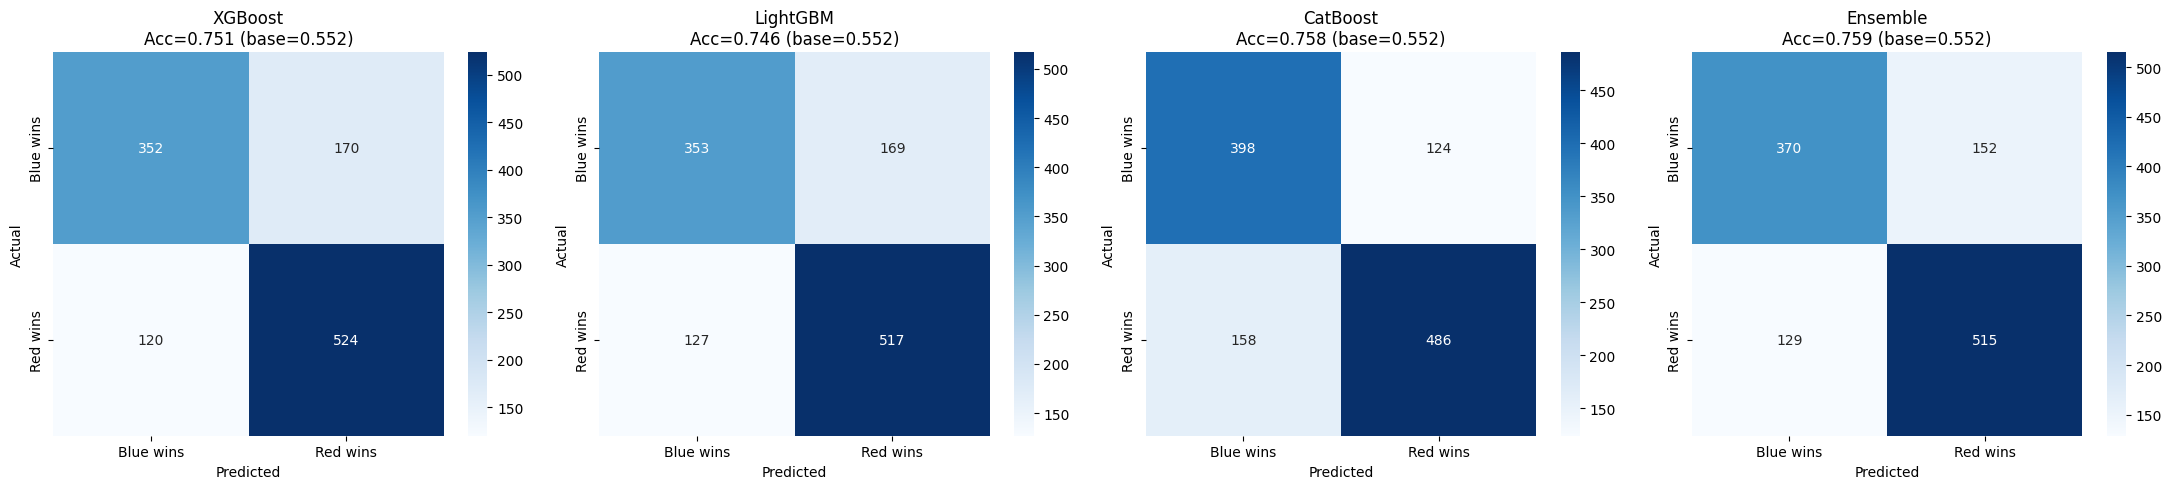


Classification Report — Ensemble:
               precision    recall  f1-score   support

Blue wins (0)       0.74      0.71      0.72       522
 Red wins (1)       0.77      0.80      0.79       644

     accuracy                           0.76      1166
    macro avg       0.76      0.75      0.76      1166
 weighted avg       0.76      0.76      0.76      1166



In [14]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

all_preds = list(models.items()) + [('Ensemble', (ens_preds, ens_probs, None))]

for ax, (name, (preds, probs, _)) in zip(axes, all_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Blue wins', 'Red wins'],
                yticklabels=['Blue wins', 'Red wins'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nAcc={acc:.3f} (base={baseline_acc:.3f})')

plt.tight_layout()
plt.savefig(f'{DATA}confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification reports ──
print("\nClassification Report — Ensemble:")
print(classification_report(y_test, ens_preds,
      target_names=['Blue wins (0)', 'Red wins (1)']))


## Predicted Probability Distributions
How confident is the model? A model that just predicts ~57% for everything
isn't useful. We want a spread of probabilities.


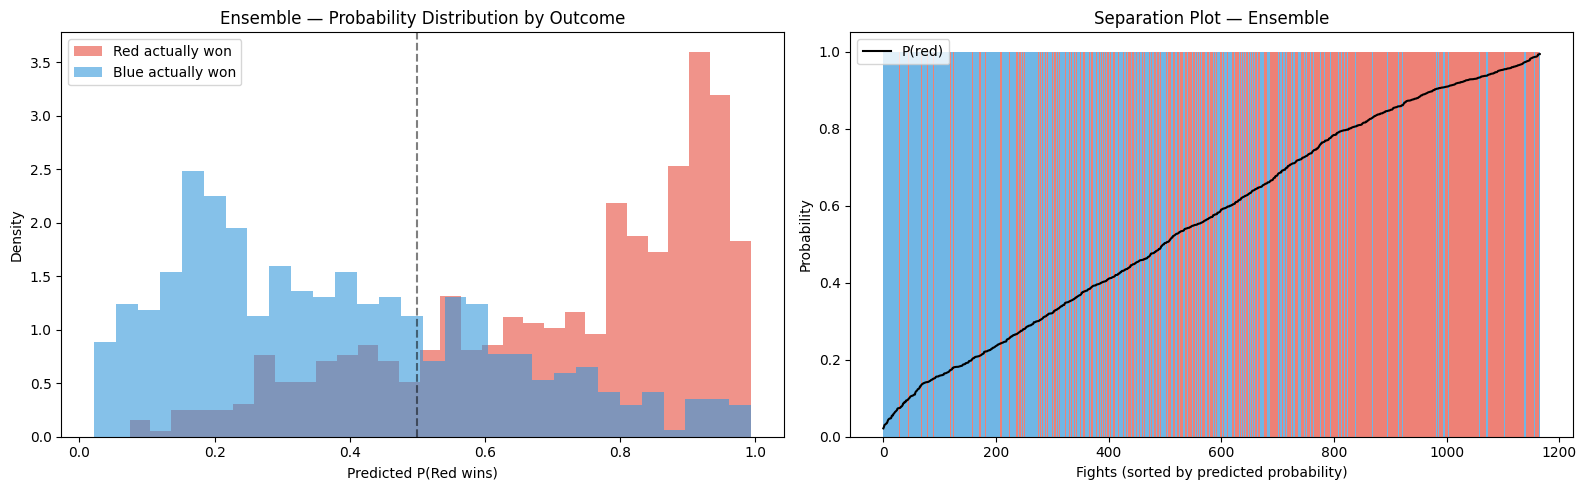

Predicted probability stats:
  Mean:   0.564
  Std:    0.282
  Min:    0.022
  Max:    0.994
  <40%:   388 fights (33.3%)
  40-60%: 229 fights (19.6%)
  >60%:   549 fights (47.1%)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Distribution of ensemble probabilities ──
ax = axes[0]
ax.hist(ens_probs[y_test == 1], bins=30, alpha=0.6, label='Red actually won', color='#e74c3c', density=True)
ax.hist(ens_probs[y_test == 0], bins=30, alpha=0.6, label='Blue actually won', color='#3498db', density=True)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Predicted P(Red wins)')
ax.set_ylabel('Density')
ax.set_title('Ensemble — Probability Distribution by Outcome')
ax.legend()

# ── Separation plot ──
ax = axes[1]
sorted_idx = np.argsort(ens_probs)
colors = ['#e74c3c' if y_test.iloc[i] == 1 else '#3498db' for i in sorted_idx]
ax.bar(range(len(ens_probs)), [1]*len(ens_probs), color=colors, width=1.0, alpha=0.7)
ax.plot(range(len(ens_probs)), ens_probs[sorted_idx], color='black', linewidth=1.5, label='P(red)')
ax.set_xlabel('Fights (sorted by predicted probability)')
ax.set_ylabel('Probability')
ax.set_title('Separation Plot — Ensemble')
ax.legend()

plt.tight_layout()
plt.savefig(f'{DATA}probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary stats ──
print(f"Predicted probability stats:")
print(f"  Mean:   {ens_probs.mean():.3f}")
print(f"  Std:    {ens_probs.std():.3f}")
print(f"  Min:    {ens_probs.min():.3f}")
print(f"  Max:    {ens_probs.max():.3f}")
print(f"  <40%:   {(ens_probs < 0.4).sum()} fights ({(ens_probs < 0.4).mean():.1%})")
print(f"  40-60%: {((ens_probs >= 0.4) & (ens_probs <= 0.6)).sum()} fights ({((ens_probs >= 0.4) & (ens_probs <= 0.6)).mean():.1%})")
print(f"  >60%:   {(ens_probs > 0.6).sum()} fights ({(ens_probs > 0.6).mean():.1%})")


## Save Models & Final Summary


In [16]:
# ── Save models ──
MODELS_DIR = '../models/' if os.path.exists('../models/') else './models/'
os.makedirs(MODELS_DIR, exist_ok=True)

xgb_model.save_model(f'{MODELS_DIR}xgb_model.json')
lgb_model.booster_.save_model(f'{MODELS_DIR}lgb_model.txt')
cat_model.save_model(f'{MODELS_DIR}catboost_model.cbm')
print(f"Models saved to {MODELS_DIR}")

# ── Save test predictions ──
test_out = test[['event_date', 'fighter_1', 'fighter_2', 'f1_win', 'weight_class']].copy()
test_out['xgb_prob'] = xgb_probs
test_out['lgb_prob'] = lgb_probs
test_out['cat_prob'] = cat_probs
test_out['ens_prob'] = ens_probs
test_out['ens_pred'] = ens_preds
test_out['correct']  = (ens_preds == y_test.values).astype(int)
test_out.to_csv(f'{DATA}test_predictions.csv', index=False)
print(f"Test predictions saved to {DATA}test_predictions.csv")

# ── Save feature list ──
with open(f'{DATA}feature_list.txt', 'w') as f:
    for feat in all_features:
        f.write(feat + '\n')
print(f"Feature list saved ({len(all_features)} features)")

# ── FINAL SUMMARY ──
print(f"\n{'='*60}")
print(f"FINAL SUMMARY")
print(f"{'='*60}")
print(f"Training period:     {train.event_date.min().date()} → {train.event_date.max().date()}")
print(f"Test period:         {test.event_date.min().date()} → {test.event_date.max().date()}")
print(f"Training fights:     {len(train)}")
print(f"Test fights:         {len(test)}")
print(f"Features:            {len(all_features)}")
print(f"Baseline (always red): {baseline_acc:.3f}")
print(f"")
print(f"{'Model':<12} {'Test Acc':>9} {'Lift':>7} {'AUC':>6} {'LogLoss':>8}")
print(f"{'─'*44}")
for name, (preds, probs, _) in models.items():
    acc = accuracy_score(y_test, preds)
    print(f"{name:<12} {acc:>9.3f} {acc-baseline_acc:>+7.3f} "
          f"{roc_auc_score(y_test, probs):>6.3f} {log_loss(y_test, probs):>8.3f}")
print(f"{'Ensemble':<12} {ens_acc:>9.3f} {ens_acc-baseline_acc:>+7.3f} "
      f"{ens_auc:>6.3f} {ens_ll:>8.3f}")
print(f"")
print(f"Profile leakage impact: {profile_impact:+.3f}")
print(f"")
print(f"Next steps:")
print(f"  1. Hyperparameter tuning (Optuna) — notebook 06")
print(f"  2. Stacked ensemble (use CV predictions as meta-features)")
print(f"  3. Betting simulation (Kelly criterion / flat bet on confident picks)")
print(f"  4. SHAP analysis for individual fight explanations")


Models saved to ../models/
Test predictions saved to ./data/test_predictions.csv
Feature list saved (310 features)

FINAL SUMMARY
Training period:     2015-01-03 → 2023-12-16
Test period:         2024-01-13 → 2026-04-11
Training fights:     4319
Test fights:         1166
Features:            310
Baseline (always red): 0.552

Model         Test Acc    Lift    AUC  LogLoss
────────────────────────────────────────────
XGBoost          0.751  +0.199  0.828    0.513
LightGBM         0.746  +0.194  0.831    0.511
CatBoost         0.758  +0.206  0.836    0.504
Ensemble         0.759  +0.207  0.837    0.499

Profile leakage impact: +0.112

Next steps:
  1. Hyperparameter tuning (Optuna) — notebook 06
  2. Stacked ensemble (use CV predictions as meta-features)
  3. Betting simulation (Kelly criterion / flat bet on confident picks)
  4. SHAP analysis for individual fight explanations
